# Parsing Rhea into a network for LipiNet

In [1]:
# import lipinet.databases  # Import the module - TODO: should implement later
import importlib

# Reload the module to ensure changes are picked up
#importlib.reload(lipinet)

# Now can use the functions after reloading the module
#from lipinet.databases import get_prior_knowledge - TODO: should implement later
from lipinet.utils import split_and_expand_large, create_nodedf_from_edgedf, check_for_split_characters

import pandas as pd

In [2]:
import plotly.express as px
import seaborn as sns 
import missingno as msno 
import matplotlib.pyplot as plt

## Parsing the manual way

In [3]:
# TODO: Implement the get_prior_knowledge function for df_rhea
# df_rhea = get_prior_knowledge('swisslipids', verbose=True)
# df_rhea
# Temporary solution below
df_rhea = pd.read_csv('../.data/Rhea-.tsv', sep='\t')
df_rhea

,Reaction identifier,Equation,Participant identifier,ChEBI name,ChEBI identifier,Enzyme class,EC number,Enzymes,Gene Ontology,Cross-reference (Reactome)
0,RHEA:23128,4-hydroxybutanoate + ATP + CoA = 4-hydroxybuta...,CHEBI:16724;CHEBI:30616;CHEBI:57287;CHEBI:5857...,4-hydroxybutanoate;ATP;CoA;4-hydroxybutanoyl-C...,CHEBI:16724;CHEBI:30616;CHEBI:57287;CHEBI:5857...,EC:6.2.1.40 4-hydroxybutyrate--CoA ligase (AMP...,EC:6.2.1.40,2,NaN,NaN
1,RHEA:23132,hydrogen sulfide + 6 oxidized [2Fe-2S]-[ferred...,CHEBI:29919;RHEA-COMP:10000;CHEBI:15377;CHEBI:...,hydrogen sulfide;[2Fe-2S](2+);H2O;sulfite;[2Fe...,CHEBI:29919;CHEBI:33737;CHEBI:15377;CHEBI:1735...,EC:1.8.7.1 assimilatory sulfite reductase (fer...,EC:1.8.7.1,9392,GO:0050311 sulfite reductase (ferredoxin) acti...,NaN
2,RHEA:23136,a primary amine + S-adenosyl-L-methionine = a ...,CHEBI:65296;CHEBI:59789;CHEBI:131823;CHEBI:578...,a primary amine;S-adenosyl-L-methionine;a meth...,CHEBI:65296;CHEBI:59789;CHEBI:131823;CHEBI:578...,EC:2.1.1.49 amine N-methyltransferase,EC:2.1.1.49,4,NaN,NaN
3,RHEA:23140,beta-nicotinamide D-ribonucleotide + H2O = D-r...,CHEBI:14649;CHEBI:15377;CHEBI:78346;CHEBI:1715...,beta-nicotinamide D-ribonucleotide;H2O;D-ribos...,CHEBI:14649;CHEBI:15377;CHEBI:78346;CHEBI:1715...,EC:3.2.2.14 NMN nucleosidase,EC:3.2.2.14,0,GO:0019160 NMN nucleosidase activity,NaN
4,RHEA:23144,N-acetyl-alpha-D-glucosamine + NAD(+) + H2O = ...,CHEBI:44278;CHEBI:57540;CHEBI:15377;CHEBI:3843...,N-acetyl-alpha-D-glucosamine;NAD(+);H2O;N-acet...,CHEBI:44278;CHEBI:57540;CHEBI:15377;CHEBI:3843...,EC:1.1.1.240 N-acetylhexosamine 1-dehydrogenase,EC:1.1.1.240,0,GO:0050120 N-acetylhexosamine 1-dehydrogenase ...,NaN
...,...,...,...,...,...,...,...,...,...,...
17417,RHEA:23108,"D-arabinono-1,4-lactone + H2O = D-arabinonate ...",CHEBI:16292;CHEBI:15377;CHEBI:16157;CHEBI:15378,"D-arabinono-1,4-lactone;H2O;D-arabinonate;H(+)",CHEBI:16292;CHEBI:15377;CHEBI:16157;CHEBI:15378,EC:3.1.1.30 D-arabinonolactonase;EC:3.1.1.120 ...,EC:3.1.1.30;EC:3.1.1.120,3,GO:0047815 D-arabinonolactonase activity,NaN
17418,RHEA:23112,6-methylsalicylate + H(+) = 3-methylphenol + CO2,CHEBI:36658;CHEBI:15378;CHEBI:17231;CHEBI:16526,6-methylsalicylate;H(+);3-methylphenol;CO2,CHEBI:36658;CHEBI:15378;CHEBI:17231;CHEBI:16526,EC:4.1.1.52 6-methylsalicylate decarboxylase,EC:4.1.1.52,2454,GO:0047596 6-methylsalicylate decarboxylase ac...,NaN
17419,RHEA:23116,4-hydroxybenzoate + ATP + CoA = 4-hydroxybenzo...,CHEBI:17879;CHEBI:30616;CHEBI:57287;CHEBI:5735...,4-hydroxybenzoate;ATP;CoA;4-hydroxybenzoyl-CoA...,CHEBI:17879;CHEBI:30616;CHEBI:57287;CHEBI:5735...,EC:6.2.1.27 4-hydroxybenzoate--CoA ligase,EC:6.2.1.27,4,GO:0018859 4-hydroxybenzoate-CoA ligase activity,NaN
17420,RHEA:23120,a dipeptide(out) + ATP + H2O = a dipeptide(in)...,CHEBI:90799;CHEBI:30616;CHEBI:15377;CHEBI:4562...,a dipeptide;ATP;H2O;ADP;phosphate;H(+),CHEBI:90799;CHEBI:30616;CHEBI:15377;CHEBI:4562...,EC:7.4.2.9 ABC-type dipeptide transporter,EC:7.4.2.9,8597,NaN,NaN


<Axes: >

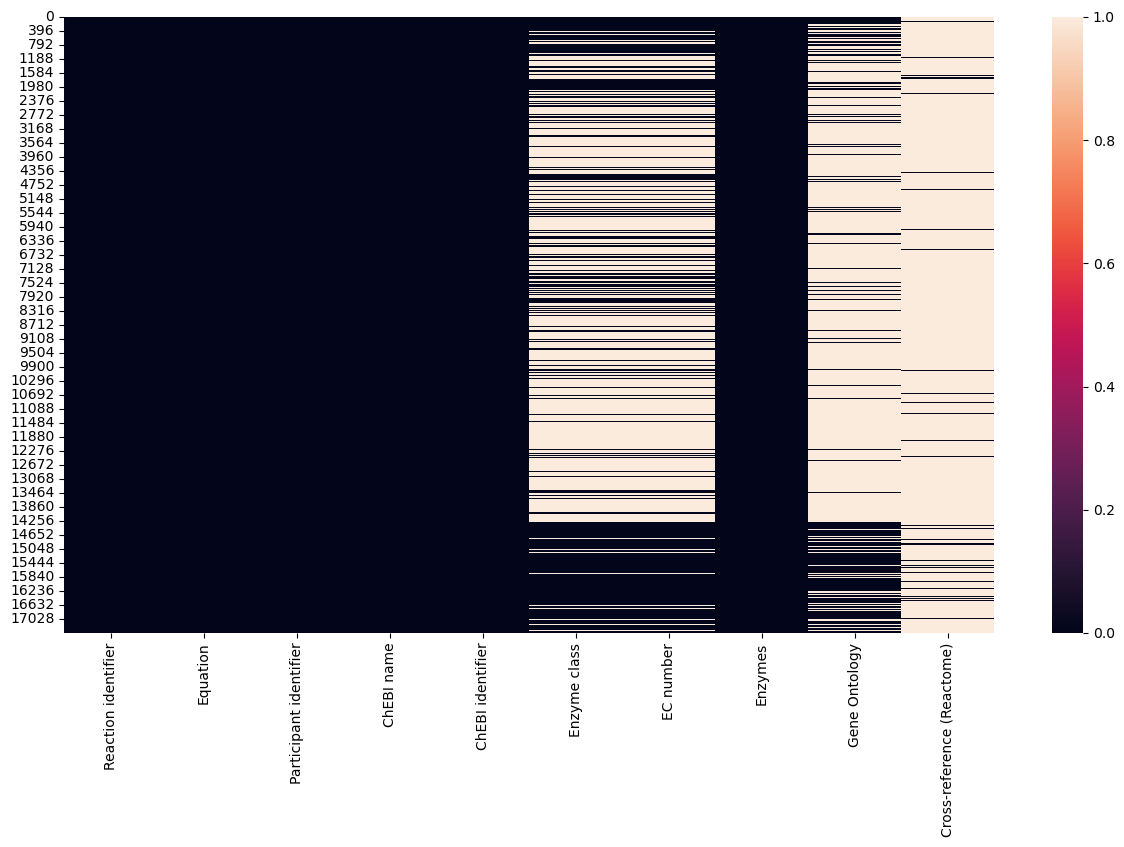

In [4]:
# Create a figure with a specific size
fig, ax = plt.subplots(figsize=(15, 8))  # Adjust the figsize parameter (width, height)

# Create the heatmap
sns.heatmap(df_rhea.isnull(), ax=ax) #sns.heatmap(df, ax=ax, cmap="YlGnBu")

What is the most common participant identifier across all entries?

In [5]:
df_rhea['Participant identifier'].str.split(';').explode().value_counts()

Participant identifier
CHEBI:15378        9717
CHEBI:15377        6337
CHEBI:15379        2779
CHEBI:57287        1555
CHEBI:58349        1316
                   ... 
RHEA-COMP:15592       1
RHEA-COMP:15607       1
RHEA-COMP:15608       1
RHEA-COMP:15591       1
CHEBI:17567           1
Name: count, Length: 14335, dtype: int64

What are the names of these molecules?

In [6]:
df_rhea['ChEBI name'].str.split(';').explode().value_counts()

ChEBI name
H(+)                           9717
H2O                            6337
O2                             2779
CoA                            1555
NADP(+)                        1316
                               ... 
(3R)-3-hydroxypentanoyl-CoA       1
3-methylsulfanylpropanal          1
(3E,5Z)-dodecadienoate            1
(3E,5Z)-dodecadienoyl-CoA         1
O-alkylglycerone                  1
Name: count, Length: 13406, dtype: int64

So it seems that Hydrogen ions, water, and O2 are the most common ChEBI molecules in Rhea

Are there any commonly represented GO terms?

In [7]:
df_rhea['Gene Ontology'].value_counts(dropna=False)

Gene Ontology
NaN                                                           13070
GO:0047640 aldose 1-dehydrogenase activity                        1
GO:0047049 (R)-2-hydroxy-fatty acid dehydrogenase activity        1
GO:0008777 acetylornithine deacetylase activity                   1
GO:0052661 S-lactaldehyde reductase activity                      1
                                                              ...  
GO:0102194 protein-fructosamine 3-kinase activity                 1
GO:0062147 L-lysine 4-chlorinase activity                         1
GO:0062146 4-chloro-allylglycine synthase activity                1
GO:0062144 L-propargylglycine synthase activity                   1
GO:0016984 ribulose-bisphosphate carboxylase activity             1
Name: count, Length: 4353, dtype: int64

It seems that all GO terms are unique, besides the ones that are NaN.

What about common enzyme classes?

In [8]:
df_rhea['Enzyme class'].value_counts()

Enzyme class
EC:1.14.13.105 monocyclic monoterpene ketone monooxygenase              13
EC:2.7.4.6 nucleoside-diphosphate kinase                                12
EC:1.14.12.23 nitroarene dioxygenase                                    12
EC:2.1.1.163 demethylmenaquinone methyltransferase                      11
EC:3.1.3.62 multiple inositol-polyphosphate phosphatase                 10
                                                                        ..
EC:1.3.1.109 butanoyl-CoA dehydrogenase complex (NAD(+), ferredoxin)     1
EC:1.3.1.108 caffeoyl-CoA reductase                                      1
EC:1.17.1.11 formate dehydrogenase (NAD(+), ferredoxin)                  1
EC:1.2.1.95 L-2-aminoadipate reductase                                   1
EC:4.1.1.39 ribulose-bisphosphate carboxylase                            1
Name: count, Length: 6044, dtype: int64

How many don't have any ec class?

In [9]:
df_rhea['EC number'].notna().value_counts()

EC number
False    9930
True     7492
Name: count, dtype: int64

What about EC number, taking into account the possibility for multiple enzyme class numbers to be assigned per reaction?

In [10]:
df_rhea['EC number'].str.split(';').explode().value_counts()

EC number
EC:3.6.1.9        14
EC:1.14.13.105    13
EC:1.14.12.23     12
EC:3.1.3.62       12
EC:2.7.4.6        12
                  ..
EC:4.2.1.162       1
EC:3.1.1.99        1
EC:1.1.1.390       1
EC:2.5.1.131       1
EC:4.1.1.39        1
Name: count, Length: 6120, dtype: int64

How common is it actually to have multiple EC numbers?

In [11]:
df_rhea['EC number'].str.split(';').str.len().value_counts()

EC number
1.0     7266
2.0      202
3.0       18
17.0       2
7.0        2
5.0        1
4.0        1
Name: count, dtype: int64

Note that the IUBMB number actually is determined by a hierarchy. Because of this, let's turn it into a nice df ready to be parsed as a hierarchy.

#### Preparing the Rhea enzyme classification (EC) info

In [12]:
def process_ec_numbers(df):
    """
    Process the 'EC number' column of the input DataFrame.

    Parameters:
        df (pd.DataFrame): A DataFrame containing an 'EC number' column.

    Returns:
        pd.DataFrame: A new DataFrame with the following columns:
            - 'EC_number': The reassembled EC number in the format 'EC:Main_Class.Subclass.Subsubclass.Serial_Number'
            - 'Main_Class': The first part of the EC number.
            - 'Subclass': The second part of the EC number.
            - 'Subsubclass': The third part of the EC number.
            - 'Serial_Number': The fourth part of the EC number.
    """
    # Split, explode, deduplicate, clean and split by '.' into a Series of lists.
    ec_num_series = df['EC number'].str.split(';')\
                        .explode()\
                        .drop_duplicates()\
                        .dropna()\
                        .str.strip('EC:')\
                        .str.split('.')
    
    # Convert the Series of lists into a DataFrame with named columns.
    df_ec = pd.DataFrame(ec_num_series.tolist(), 
                         columns=["Main_Class", "Subclass", "Subsubclass", "Serial_Number"])
    
    # Create a new column with the reassembled EC number in the original format.
    df_ec.insert(0, 'EC_number', 
                 'EC:' + df_ec["Main_Class"].astype(str) + '.' +
                 df_ec["Subclass"].astype(str) + '.' +
                 df_ec["Subsubclass"].astype(str) + '.' +
                 df_ec["Serial_Number"].astype(str))
    
    return df_ec

In [13]:
# Assuming df_rhea is your original DataFrame with the 'EC number' column.
df_ec = process_ec_numbers(df_rhea)
df_ec

,EC_number,Main_Class,Subclass,Subsubclass,Serial_Number
0,EC:6.2.1.40,6,2,1,40
1,EC:1.8.7.1,1,8,7,1
2,EC:2.1.1.49,2,1,1,49
3,EC:3.2.2.14,3,2,2,14
4,EC:1.1.1.240,1,1,1,240
...,...,...,...,...,...
6115,EC:3.1.1.30,3,1,1,30
6116,EC:4.1.1.52,4,1,1,52
6117,EC:6.2.1.27,6,2,1,27
6118,EC:7.4.2.9,7,4,2,9


In [14]:
def build_rhea_ec_edges_and_nodes(df_ec: pd.DataFrame):
    """
    Given a DataFrame with EC hierarchy columns:
        Main_Class, Subclass, Subsubclass, EC_number,
    this function creates:
      - A DataFrame of edges linking each hierarchical level.
      - A DataFrame of unique nodes with a 'ec_level' column 
        indicating the node's level in the hierarchy.
    """

    # -- Make a copy so we don't modify the original df in-place
    df = df_ec.copy()

    # 1) Build the node representations for each hierarchy level
    #    (convert to string just in case they're numeric)
    df["main_node"] = "EC:" + df["Main_Class"].astype(str)
    df["subclass_node"] = (
        "EC:" + df["Main_Class"].astype(str) 
        + "." + df["Subclass"].astype(str)
    )
    df["subsubclass_node"] = (
        "EC:" + df["Main_Class"].astype(str) 
        + "." + df["Subclass"].astype(str)
        + "." + df["Subsubclass"].astype(str)
    )

    # 2) Create edges for each hierarchical link and label them
    edges1 = df[["main_node", "subclass_node"]].rename(
        columns={"main_node": "source_id", "subclass_node": "target_id"}
    )
    edges1["ec_level"] = "main_class->subclass"

    edges2 = df[["subclass_node", "subsubclass_node"]].rename(
        columns={"subclass_node": "source_id", "subsubclass_node": "target_id"}
    )
    edges2["ec_level"] = "subclass->subsubclass"

    edges3 = df[["subsubclass_node", "EC_number"]].rename(
        columns={"subsubclass_node": "source_id", "EC_number": "target_id"}
    )
    edges3["ec_level"] = "subsubclass->EC_number"

    # Concatenate edges and drop duplicates
    edges_df = pd.concat([edges1, edges2, edges3], ignore_index=True).drop_duplicates()

    # Add the additional columns for your graph structure
    edges_df["source_layer"] = "rhea_ec"
    edges_df["target_layer"] = "rhea_ec"
    edges_df["interlayer"] = False

    # 3) Build a node DataFrame from all unique source/target IDs
    nodes_df = pd.DataFrame(
        pd.concat([edges_df["source_id"], edges_df["target_id"]]).unique(),
        columns=["node_id"]
    )
    nodes_df["layer"] = "rhea_ec"  # same layer for all

    # 4) Build a small lookup table to label each node with ec_level
    #    We'll mark each node as either "main_class", "subclass", "subsubclass", or "full_ec".
    df_main = (
        df[["main_node"]].drop_duplicates().rename(columns={"main_node": "node_id"})
    )
    df_main["ec_level"] = "main_class"

    df_sub = (
        df[["subclass_node"]].drop_duplicates().rename(columns={"subclass_node": "node_id"})
    )
    df_sub["ec_level"] = "subclass"

    df_subsub = (
        df[["subsubclass_node"]].drop_duplicates().rename(columns={"subsubclass_node": "node_id"})
    )
    df_subsub["ec_level"] = "subsubclass"

    df_full = (
        df[["EC_number"]].drop_duplicates().rename(columns={"EC_number": "node_id"})
    )
    df_full["ec_level"] = "full_ec"

    df_nodes_level = pd.concat([df_main, df_sub, df_subsub, df_full], ignore_index=True)
    df_nodes_level.drop_duplicates(subset="node_id", inplace=True)

    # 5) Merge the node-level info into the nodes_df
    nodes_df = nodes_df.merge(df_nodes_level, on="node_id", how="left")

    # Return the final DataFrames
    return edges_df, nodes_df

# Example usage:
# df_edges_rhea_ec, df_nodes_rhea_ec = build_rhea_ec_edges_and_nodes(df_ec)

In [15]:
df_edges_rhea_ec, df_nodes_rhea_ec = build_rhea_ec_edges_and_nodes(df_ec)

In [16]:
df_edges_rhea_ec

,source_id,target_id,ec_level,source_layer,target_layer,interlayer
0,EC:6,EC:6.2,main_class->subclass,rhea_ec,rhea_ec,False
1,EC:1,EC:1.8,main_class->subclass,rhea_ec,rhea_ec,False
2,EC:2,EC:2.1,main_class->subclass,rhea_ec,rhea_ec,False
3,EC:3,EC:3.2,main_class->subclass,rhea_ec,rhea_ec,False
4,EC:1,EC:1.1,main_class->subclass,rhea_ec,rhea_ec,False
...,...,...,...,...,...,...
18355,EC:3.1.1,EC:3.1.1.30,subsubclass->EC_number,rhea_ec,rhea_ec,False
18356,EC:4.1.1,EC:4.1.1.52,subsubclass->EC_number,rhea_ec,rhea_ec,False
18357,EC:6.2.1,EC:6.2.1.27,subsubclass->EC_number,rhea_ec,rhea_ec,False
18358,EC:7.4.2,EC:7.4.2.9,subsubclass->EC_number,rhea_ec,rhea_ec,False


In [17]:
df_nodes_rhea_ec

,node_id,layer,ec_level
0,EC:6,rhea_ec,main_class
1,EC:1,rhea_ec,main_class
2,EC:2,rhea_ec,main_class
3,EC:3,rhea_ec,main_class
4,EC:4,rhea_ec,main_class
...,...,...,...
6451,EC:3.1.1.30,rhea_ec,full_ec
6452,EC:4.1.1.52,rhea_ec,full_ec
6453,EC:6.2.1.27,rhea_ec,full_ec
6454,EC:7.4.2.9,rhea_ec,full_ec


#### Preparing the remaining Rhea info

Now we have created the df of nodes and edges for just the __enzyme classification__ info. We want to also create nodes and edges for __all relevant__ rhea info too.

In [18]:
def explode_columns(df, columns, delimiter=";"):
    """
    Split and explode the specified columns of a DataFrame.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        columns (list of str): List of column names to split by the delimiter.
        delimiter (str): The delimiter to use when splitting the column values.

    Returns:
        pd.DataFrame: A new DataFrame with the specified columns exploded.

    Note:
        Each row in the specified columns must produce lists of the same length.
    """
    df = df.copy()
    for col in columns:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' does not exist in the DataFrame.")
        df[col] = df[col].str.split(delimiter)
    return df.explode(columns)

In [19]:
df_rhea_exploded = explode_columns(df_rhea, ["ChEBI identifier", "ChEBI name"])
df_rhea_exploded

,Reaction identifier,Equation,Participant identifier,ChEBI name,ChEBI identifier,Enzyme class,EC number,Enzymes,Gene Ontology,Cross-reference (Reactome)
0,RHEA:23128,4-hydroxybutanoate + ATP + CoA = 4-hydroxybuta...,CHEBI:16724;CHEBI:30616;CHEBI:57287;CHEBI:5857...,4-hydroxybutanoate,CHEBI:16724,EC:6.2.1.40 4-hydroxybutyrate--CoA ligase (AMP...,EC:6.2.1.40,2,NaN,NaN
0,RHEA:23128,4-hydroxybutanoate + ATP + CoA = 4-hydroxybuta...,CHEBI:16724;CHEBI:30616;CHEBI:57287;CHEBI:5857...,ATP,CHEBI:30616,EC:6.2.1.40 4-hydroxybutyrate--CoA ligase (AMP...,EC:6.2.1.40,2,NaN,NaN
0,RHEA:23128,4-hydroxybutanoate + ATP + CoA = 4-hydroxybuta...,CHEBI:16724;CHEBI:30616;CHEBI:57287;CHEBI:5857...,CoA,CHEBI:57287,EC:6.2.1.40 4-hydroxybutyrate--CoA ligase (AMP...,EC:6.2.1.40,2,NaN,NaN
0,RHEA:23128,4-hydroxybutanoate + ATP + CoA = 4-hydroxybuta...,CHEBI:16724;CHEBI:30616;CHEBI:57287;CHEBI:5857...,4-hydroxybutanoyl-CoA,CHEBI:58574,EC:6.2.1.40 4-hydroxybutyrate--CoA ligase (AMP...,EC:6.2.1.40,2,NaN,NaN
0,RHEA:23128,4-hydroxybutanoate + ATP + CoA = 4-hydroxybuta...,CHEBI:16724;CHEBI:30616;CHEBI:57287;CHEBI:5857...,AMP,CHEBI:456215,EC:6.2.1.40 4-hydroxybutyrate--CoA ligase (AMP...,EC:6.2.1.40,2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
17421,RHEA:23124,2 (2R)-3-phosphoglycerate + 2 H(+) = D-ribulos...,CHEBI:58272;CHEBI:15378;CHEBI:57870;CHEBI:1652...,(2R)-3-phosphoglycerate,CHEBI:58272,EC:4.1.1.39 ribulose-bisphosphate carboxylase,EC:4.1.1.39,172298,GO:0016984 ribulose-bisphosphate carboxylase a...,NaN
17421,RHEA:23124,2 (2R)-3-phosphoglycerate + 2 H(+) = D-ribulos...,CHEBI:58272;CHEBI:15378;CHEBI:57870;CHEBI:1652...,H(+),CHEBI:15378,EC:4.1.1.39 ribulose-bisphosphate carboxylase,EC:4.1.1.39,172298,GO:0016984 ribulose-bisphosphate carboxylase a...,NaN
17421,RHEA:23124,2 (2R)-3-phosphoglycerate + 2 H(+) = D-ribulos...,CHEBI:58272;CHEBI:15378;CHEBI:57870;CHEBI:1652...,"D-ribulose 1,5-bisphosphate",CHEBI:57870,EC:4.1.1.39 ribulose-bisphosphate carboxylase,EC:4.1.1.39,172298,GO:0016984 ribulose-bisphosphate carboxylase a...,NaN
17421,RHEA:23124,2 (2R)-3-phosphoglycerate + 2 H(+) = D-ribulos...,CHEBI:58272;CHEBI:15378;CHEBI:57870;CHEBI:1652...,CO2,CHEBI:16526,EC:4.1.1.39 ribulose-bisphosphate carboxylase,EC:4.1.1.39,172298,GO:0016984 ribulose-bisphosphate carboxylase a...,NaN


In [20]:
df_edges_rhea_reactiontochebi = df_rhea_exploded.copy()
df_edges_rhea_reactiontochebi = df_edges_rhea_reactiontochebi[['Reaction identifier', 'ChEBI identifier']] #,'ChEBI name'
df_edges_rhea_reactiontochebi.columns = ['target_id', 'source_id']
df_edges_rhea_reactiontochebi['source_layer'] = 'rhea_chebiid'
df_edges_rhea_reactiontochebi['target_layer'] = 'rhea_reactionid'
df_edges_rhea_reactiontochebi['interlayer'] = False
df_edges_rhea_reactiontochebi

,target_id,source_id,source_layer,target_layer,interlayer
0,RHEA:23128,CHEBI:16724,rhea_chebiid,rhea_reactionid,False
0,RHEA:23128,CHEBI:30616,rhea_chebiid,rhea_reactionid,False
0,RHEA:23128,CHEBI:57287,rhea_chebiid,rhea_reactionid,False
0,RHEA:23128,CHEBI:58574,rhea_chebiid,rhea_reactionid,False
0,RHEA:23128,CHEBI:456215,rhea_chebiid,rhea_reactionid,False
...,...,...,...,...,...
17421,RHEA:23124,CHEBI:58272,rhea_chebiid,rhea_reactionid,False
17421,RHEA:23124,CHEBI:15378,rhea_chebiid,rhea_reactionid,False
17421,RHEA:23124,CHEBI:57870,rhea_chebiid,rhea_reactionid,False
17421,RHEA:23124,CHEBI:16526,rhea_chebiid,rhea_reactionid,False


In [21]:
df_nodes_rhea_chebiid = df_rhea_exploded[['ChEBI identifier', 'ChEBI name']].rename(
    columns={'ChEBI identifier': 'node_id', 'ChEBI name': 'chebi_name'}
).assign(layer='rhea_chebiid').drop_duplicates()
# df_nodes_rhea_chebiid

df_nodes_rhea_reactionid = df_rhea[['Reaction identifier','Equation','ChEBI identifier', 'ChEBI name','Participant identifier','Enzyme class','EC number','Enzymes','Gene Ontology','Cross-reference (Reactome)']].rename(
    columns={'Reaction identifier': 'node_id', 'ChEBI name': 'chebi_name'}
).assign(layer='rhea_reactionid').drop_duplicates()
# df_nodes_rhea_reactionid

# df_nodes_rhea_reactiontochebi = pd.concat([df_nodes_rhea_chebiid, df_nodes_rhea_reactionid])
# df_nodes_rhea_reactiontochebi

df_rhea_exploded_enzymeclass = explode_columns(df_rhea, ["EC number"], delimiter=';')
df_rhea_exploded_enzymeclass

df_edges_rhea_reactiontoenzymeclass = df_rhea_exploded_enzymeclass[['Reaction identifier', 'EC number']].rename(
    columns={'Reaction identifier': 'source_id', 'EC number': 'target_id'}
).assign(source_layer='rhea_reactionid', target_layer='rhea_ec', interlayer=False).drop_duplicates()
df_edges_rhea_reactiontoenzymeclass

df_edges_rhea_reactiontochebi_comb = pd.concat([df_edges_rhea_reactiontochebi, df_edges_rhea_reactiontoenzymeclass,])
df_edges_rhea_reactiontochebi_comb

# Remake nodes with enzyme class included
df_nodes_rhea_reactiontochebi_comb = pd.concat([df_nodes_rhea_chebiid, 
                                           df_nodes_rhea_reactionid, 
                                           df_nodes_rhea_ec])

In [22]:
df_nodes_rhea_reactiontochebi_comb

,node_id,chebi_name,layer,Equation,ChEBI identifier,Participant identifier,Enzyme class,EC number,Enzymes,Gene Ontology,Cross-reference (Reactome),ec_level
0,CHEBI:16724,4-hydroxybutanoate,rhea_chebiid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,CHEBI:30616,ATP,rhea_chebiid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,CHEBI:57287,CoA,rhea_chebiid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,CHEBI:58574,4-hydroxybutanoyl-CoA,rhea_chebiid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,CHEBI:456215,AMP,rhea_chebiid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
6451,EC:3.1.1.30,NaN,rhea_ec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,full_ec
6452,EC:4.1.1.52,NaN,rhea_ec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,full_ec
6453,EC:6.2.1.27,NaN,rhea_ec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,full_ec
6454,EC:7.4.2.9,NaN,rhea_ec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,full_ec


In [23]:
df_edges_rhea_reactiontochebi_comb

,target_id,source_id,source_layer,target_layer,interlayer
0,RHEA:23128,CHEBI:16724,rhea_chebiid,rhea_reactionid,False
0,RHEA:23128,CHEBI:30616,rhea_chebiid,rhea_reactionid,False
0,RHEA:23128,CHEBI:57287,rhea_chebiid,rhea_reactionid,False
0,RHEA:23128,CHEBI:58574,rhea_chebiid,rhea_reactionid,False
0,RHEA:23128,CHEBI:456215,rhea_chebiid,rhea_reactionid,False
...,...,...,...,...,...
17417,EC:3.1.1.120,RHEA:23108,rhea_reactionid,rhea_ec,False
17418,EC:4.1.1.52,RHEA:23112,rhea_reactionid,rhea_ec,False
17419,EC:6.2.1.27,RHEA:23116,rhea_reactionid,rhea_ec,False
17420,EC:7.4.2.9,RHEA:23120,rhea_reactionid,rhea_ec,False


Get all chebi ids

In [24]:
df_nodes_rhea_reactiontochebi_comb[df_nodes_rhea_reactiontochebi_comb['layer']=='rhea_chebiid']['node_id'].drop_duplicates()

0         CHEBI:16724
0         CHEBI:30616
0         CHEBI:57287
0         CHEBI:58574
0        CHEBI:456215
             ...     
17405     CHEBI:16698
17407    CHEBI:134249
17409     CHEBI:57329
17411     CHEBI:71410
17412     CHEBI:17567
Name: node_id, Length: 13406, dtype: object

## Using the LipiNet `parse_rhea` function

The LipiNet `parse_rhea` function automatically runs through all of the same steps as we have just covered.

In [25]:
from lipinet.parse_rhea import parse_rhea_data

rhea_results = parse_rhea_data(verbose=False)
df_rhea_nodes = rhea_results['df_nodes']
df_rhea_edges = rhea_results['df_edges']

In [26]:
df_rhea_nodes

,node_id,Equation,ChEBI identifier,chebi_name,Participant identifier,Enzyme class,EC number,Enzymes,Gene Ontology,Cross-reference (Reactome),layer,ec_level
0,RHEA:23128,4-hydroxybutanoate + ATP + CoA = 4-hydroxybuta...,CHEBI:16724;CHEBI:30616;CHEBI:57287;CHEBI:5857...,4-hydroxybutanoate;ATP;CoA;4-hydroxybutanoyl-C...,CHEBI:16724;CHEBI:30616;CHEBI:57287;CHEBI:5857...,EC:6.2.1.40 4-hydroxybutyrate--CoA ligase (AMP...,EC:6.2.1.40,2.0,NaN,NaN,rhea_reactionid,NaN
1,RHEA:23132,hydrogen sulfide + 6 oxidized [2Fe-2S]-[ferred...,CHEBI:29919;CHEBI:33737;CHEBI:15377;CHEBI:1735...,hydrogen sulfide;[2Fe-2S](2+);H2O;sulfite;[2Fe...,CHEBI:29919;RHEA-COMP:10000;CHEBI:15377;CHEBI:...,EC:1.8.7.1 assimilatory sulfite reductase (fer...,EC:1.8.7.1,9392.0,GO:0050311 sulfite reductase (ferredoxin) acti...,NaN,rhea_reactionid,NaN
2,RHEA:23136,a primary amine + S-adenosyl-L-methionine = a ...,CHEBI:65296;CHEBI:59789;CHEBI:131823;CHEBI:578...,a primary amine;S-adenosyl-L-methionine;a meth...,CHEBI:65296;CHEBI:59789;CHEBI:131823;CHEBI:578...,EC:2.1.1.49 amine N-methyltransferase,EC:2.1.1.49,4.0,NaN,NaN,rhea_reactionid,NaN
3,RHEA:23140,beta-nicotinamide D-ribonucleotide + H2O = D-r...,CHEBI:14649;CHEBI:15377;CHEBI:78346;CHEBI:1715...,beta-nicotinamide D-ribonucleotide;H2O;D-ribos...,CHEBI:14649;CHEBI:15377;CHEBI:78346;CHEBI:1715...,EC:3.2.2.14 NMN nucleosidase,EC:3.2.2.14,0.0,GO:0019160 NMN nucleosidase activity,NaN,rhea_reactionid,NaN
4,RHEA:23144,N-acetyl-alpha-D-glucosamine + NAD(+) + H2O = ...,CHEBI:44278;CHEBI:57540;CHEBI:15377;CHEBI:3843...,N-acetyl-alpha-D-glucosamine;NAD(+);H2O;N-acet...,CHEBI:44278;CHEBI:57540;CHEBI:15377;CHEBI:3843...,EC:1.1.1.240 N-acetylhexosamine 1-dehydrogenase,EC:1.1.1.240,0.0,GO:0050120 N-acetylhexosamine 1-dehydrogenase ...,NaN,rhea_reactionid,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
37279,EC:3.1.1.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec
37280,EC:4.1.1.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec
37281,EC:6.2.1.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec
37282,EC:7.4.2.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rhea_ec,full_ec


In [27]:
df_rhea_edges

,source_id,target_id,ec_level,source_layer,target_layer,interlayer,edge_type
0,EC:6,EC:6.2,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
1,EC:1,EC:1.8,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
2,EC:2,EC:2.1,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
3,EC:3,EC:3.2,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
4,EC:1,EC:1.1,main_class->subclass,rhea_ec,rhea_ec,False,ec_hierarchy
...,...,...,...,...,...,...,...
106205,RHEA:23108,EC:3.1.1.120,NaN,rhea_reactionid,rhea_ec,False,reaction_ec
106206,RHEA:23112,EC:4.1.1.52,NaN,rhea_reactionid,rhea_ec,False,reaction_ec
106207,RHEA:23116,EC:6.2.1.27,NaN,rhea_reactionid,rhea_ec,False,reaction_ec
106208,RHEA:23120,EC:7.4.2.9,NaN,rhea_reactionid,rhea_ec,False,reaction_ec


In [30]:
df_rhea_edges['ec_level'].value_counts(dropna=False)

ec_level
NaN                       99761
subsubclass->EC_number     6120
subclass->subsubclass       253
main_class->subclass         76
Name: count, dtype: int64

In [31]:
df_rhea_nodes['ec_level'].value_counts(dropna=False)

ec_level
NaN            30828
full_ec         6120
subsubclass      253
subclass          76
main_class         7
Name: count, dtype: int64